# Quantum EV Charging Optimizer: end-to-end demo

**Pipeline:** AI demand forecast → QUBO / Ising Hamiltonian → QAOA on Qiskit → charging schedule → comparison with classical methods.

Every cell runs on a laptop in well under a minute. Run top to bottom with *Kernel → Restart & Run All*.

| Step | What happens |
|---|---|
| 1 | Train a gradient-boosted demand forecaster and predict tomorrow's feeder load |
| 2 | Turn "which vehicle charges where and when" into a QUBO, then an Ising Hamiltonian |
| 3 | Classical references: first-come-first-served (FCFS) and the exact optimum by brute force |
| 4 | Sanity check QAOA on a 4-qubit toy instance |
| 5 | Constraint-preserving XY-mixer QAOA on the 15-qubit demo instance |
| 6 | Standard X-mixer QAOA for comparison |
| 7 | Solution quality versus circuit depth |
| 8 | Final schedules, load profile and results table |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # repo root, so `evq` imports work from notebooks/
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.width", 160)

from evq.data import generate_site_load
from evq.forecast import train_and_forecast, slot_loads
from evq.problem import (make_instance, build_qubo, bit_matrix, all_energies, feasibility_mask,
                         bits_to_assignment, schedule_metrics)
from evq.baselines import fcfs, brute_force, simulated_annealing
from evq.qaoa import qubo_to_ising, ising_operator, qaoa_circuit, solve_qaoa
from evq import viz
import qiskit; print("Qiskit", qiskit.__version__)

Qiskit 2.5.2


## 1. AI demand forecast

The repo ships a synthetic 90-day hourly load series for one charging feeder (morning and evening peaks,
weekend effect, heat effect, growing EV adoption) so the demo runs offline. Any real hourly series, for
example an aggregated slice of ACN-Data, can be dropped in instead.

A `HistGradientBoostingRegressor` uses hour, weekday, temperature and lagged demand. Two quantile models
give a P10 to P90 band. We score it on a held-out week against the seasonal-naive baseline (same hour yesterday).

{'mae_model_kw': 2.34, 'mae_seasonal_naive_kw': 3.28, 'improvement_pct': 28.89, 'target_day_mae_kw': 2.94}
Forecast base load (kW): [41.2, 41.5, 29.1]


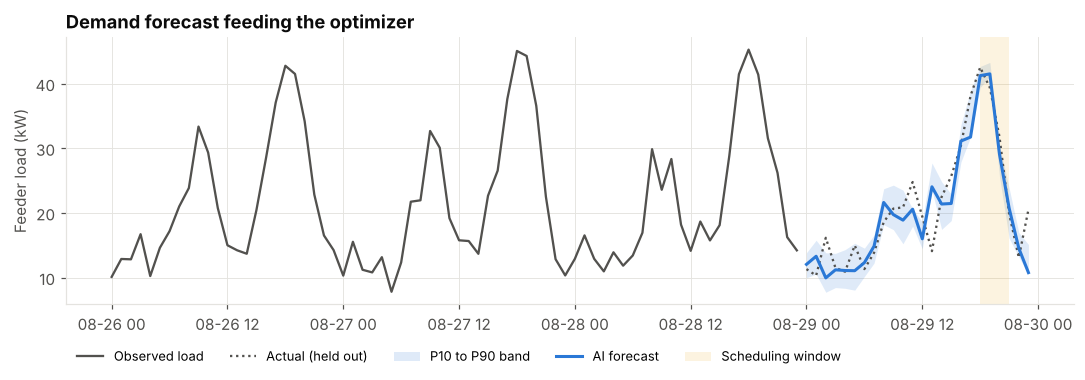

In [2]:
df = generate_site_load(days=90, seed=42)
fc = train_and_forecast(df)
print({k: round(v, 2) for k, v in fc.metrics.items()})

HOURS = [18, 19, 20]
base_load = slot_loads(fc, HOURS)          # forecast background load for the 3 evening slots
print("Forecast base load (kW):", [round(x, 1) for x in base_load])
viz.forecast_plot(fc, HOURS);

## 2. Problem formulation

**Scenario:** 4 vehicles, 2 stations (Hub A 22 kW, Mall B 11 kW), 3 one-hour evening slots.
Each vehicle has an energy request, an arrival slot, a last allowed slot and possibly a detour cost
for a less convenient station.

**Decision variable:** $x_{vst} = 1$ if vehicle $v$ charges at station $s$ in slot $t$.
Variables are only created for physically possible choices (inside the time window, station powerful enough),
which keeps the qubit count at 15.

**Cost (Rs):**

$$H_{\text{cost}} = \sum_{v,s,t}\big(\tau_t E_v + w\,\Delta t_v + \delta_{v,s}\big)x_{vst} \;+\; \gamma\sum_t\Big(\hat d_t + \sum_{v,s}E_v x_{vst}\Big)^2$$

$\tau_t$ is the time-of-day tariff and $\hat d_t$ is the **AI forecast**. The forecast enters through the
grid-peak term, so a busier predicted slot becomes more expensive to add load to.

**Penalties:**

$$H_A = A\sum_v\Big(1-\sum_{s,t}x_{vst}\Big)^2 \qquad H_B = B\sum_{s,t}\sum_{v<v'}x_{vst}x_{v'st}$$

$A = B$ is set automatically to 1.5 times the largest saving any single violation could buy, so the
lowest-energy state is always a valid schedule (checked below).

In [3]:
inst = make_instance("demo", base_load)
q = build_qubo(inst)
pd.DataFrame([{"vehicle": v.name, "energy_kWh": v.energy_kwh,
               "arrives": inst.slot_labels[v.arrival], "last_slot": inst.slot_labels[v.departure],
               "detour": v.detour} for v in inst.vehicles])

,vehicle,energy_kWh,arrives,last_slot,detour
0,V0 Fleet cab,20,18:00,20:00,{}
1,V1 Commuter,11,18:00,20:00,{1: 20}
2,V2 Delivery van,18,18:00,19:00,{}
3,V3 Resident,7,19:00,20:00,{0: 15}


In [4]:
h, J, const = qubo_to_ising(q.Q, q.offset)
H = ising_operator(h, J, q.n)
print(f"qubits: {q.n}   penalty A=B={q.penalty:.1f}")
print(f"Ising Hamiltonian: {len(H)} Pauli terms ({int((abs(h)>1e-12).sum())} Z, {len(J)} ZZ)")
print("first terms:", H[:5])
print("variable map:", [(inst.vehicles[v].name.split()[0], inst.stations[s].name.split()[0]+" "+inst.stations[s].name.split()[1], inst.slot_labels[t]) for v,s,t in q.variables[:5]], "...")

qubits: 15   penalty A=B=404.1
Ising Hamiltonian: 66 Pauli terms (15 Z, 51 ZZ)
first terms: SparsePauliOp(['IIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIZI', 'IIIIIIIIIIIIZII', 'IIIIIIIIIIIZIII', 'IIIIIIIIIIZIIII'],
              coeffs=[ -527.60836588+0.j,  -629.04247295+0.j,  -501.94074102+0.j,
 -1078.20112055+0.j, -1182.82737094+0.j])
variable map: [('V0', 'Hub A', '18:00'), ('V0', 'Hub A', '19:00'), ('V0', 'Hub A', '20:00'), ('V1', 'Hub A', '18:00'), ('V1', 'Hub A', '19:00')] ...


## 3. Classical references

With 15 variables we can enumerate all 32,768 bitstrings, which gives the exact optimum to grade QAOA against.
FCFS is the naive policy most chargers use today: whoever arrives first takes the earliest free compatible charger.

In [5]:
X = bit_matrix(q.n)
E = all_energies(q.Q, q.offset, X)          # energy of every bitstring
feas = feasibility_mask(q, inst, X)         # which bitstrings are valid schedules
print("valid schedules:", int(feas.sum()), "of", 2**q.n)
print("global minimum is a valid schedule:", bool(feas[np.argmin(E)]))

opt_bits, opt_E = brute_force(E, feas)
assign = {"FCFS": fcfs(inst), "Classical optimum": bits_to_assignment(opt_bits, q)}
pd.DataFrame({k: schedule_metrics(a, inst) for k, a in assign.items()}).T[
    ["feasible", "peak_load_kw", "energy_cost_rs", "avg_wait_slots", "detour_rs", "objective_rs"]]

valid schedules: 33 of 32768
global minimum is a valid schedule: True


,feasible,peak_load_kw,energy_cost_rs,avg_wait_slots,detour_rs,objective_rs
FCFS,True,72.24,507.0,0.25,20.0,751.76
Classical optimum,True,59.51,419.5,1.0,0.0,667.8


## 4. QAOA sanity check on a 4-qubit toy instance

Two vehicles, one station, two slots. One layer of constraint-preserving QAOA should already find the optimum.
The circuit shows the three building blocks: a W state per vehicle, the cost layer (RZ and RZZ) and the XY mixer (XX+YY).

found optimum: True | P(optimal) = 0.285 | fast simulator vs Qiskit fidelity = 1.0


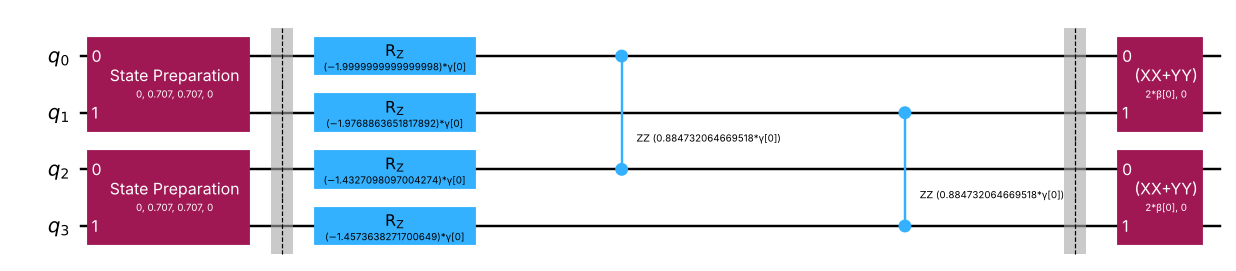

In [6]:
toy = make_instance("toy", base_load[:2]); tq = build_qubo(toy)
tX = bit_matrix(tq.n); tE = all_energies(tq.Q, tq.offset, tX); tF = feasibility_mask(tq, toy, tX)
tr = solve_qaoa(tq.Q_xy, tq.offset_obj, tE, tF, p=1, groups=tq.groups)
print("found optimum:", tr.sampled_optimal, "| P(optimal) =", round(tr.p_optimal, 3),
      "| fast simulator vs Qiskit fidelity =", round(tr.sim_fidelity, 10))
th, tJ, _ = qubo_to_ising(tq.Q_xy, tq.offset_obj)
small, _ = qaoa_circuit(th, tJ, tq.n, 1, tq.groups)
small.draw("mpl", fold=-1, scale=0.8);

## 5. Constraint-preserving QAOA on the 15-qubit demo

**Why an XY mixer?** In standard QAOA the mixer flips single bits, so most of the search happens in
states where a vehicle charges twice or not at all. Here each vehicle's variables form a one-hot block that starts in a W state,
and the XX+YY mixer only moves the "1" inside its block. The rule "each vehicle charges exactly once" therefore holds for every
state the circuit can reach, and only the charger-sharing penalty is left in the cost layer.

**Training:** COBYLA minimises the CVaR (best 25% of outcomes) of the energy. Depth grows from 1 to p with an INTERP warm start.
The trained circuit is then executed with Qiskit's `StatevectorSampler` (4096 shots) and the best valid measured schedule is returned.

In [7]:
P = 5
xy = solve_qaoa(q.Q_xy, q.offset_obj, E, feas, p=P, alpha=0.25, groups=q.groups, seed=7)
pd.Series(xy.summary())

mixer                                                                         XY
p                                                                              5
cvar_alpha                                                                  0.25
qubits                                                                        15
transpiled_depth                                                             613
cx_gates                                                                     523
cost_evaluations                                                            1513
runtime_s                                                                   12.9
shots                                                                       4096
prob_feasible                                                              0.588
prob_optimal                                                              0.1149
found_optimum                                                               True
gap_pct                     

A uniformly random valid schedule would be optimal with probability 0.0303 | XY-QAOA: 0.1149


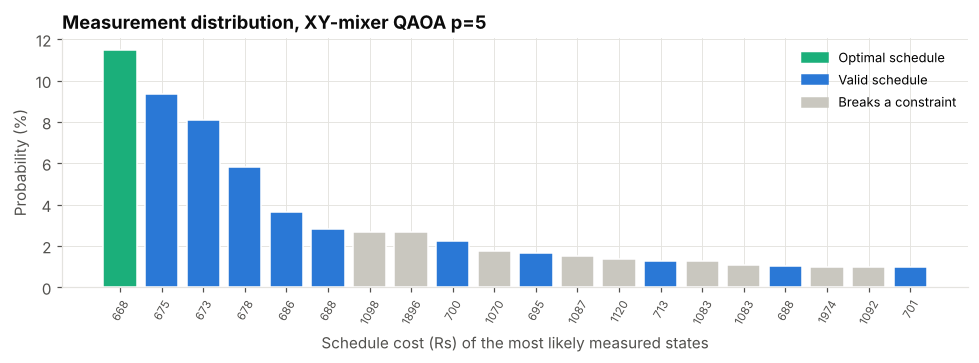

In [8]:
viz.distribution_plot(xy, E, feas);
print("A uniformly random valid schedule would be optimal with probability",
      round(1 / feas.sum(), 4), "| XY-QAOA:", round(xy.p_optimal, 4))

## 6. Standard X-mixer QAOA for comparison

Same Hamiltonian, same depth and optimizer, but the usual transverse-field mixer and all constraints as penalties.

,mixer,p,qubits,cx_gates,prob_feasible,prob_optimal,found_optimum,gap_pct,runtime_s
0,XY,5,15,523,0.5880,0.1149,True,0.0,12.90
1,X,5,15,510,0.0424,0.0013,True,0.0,21.39


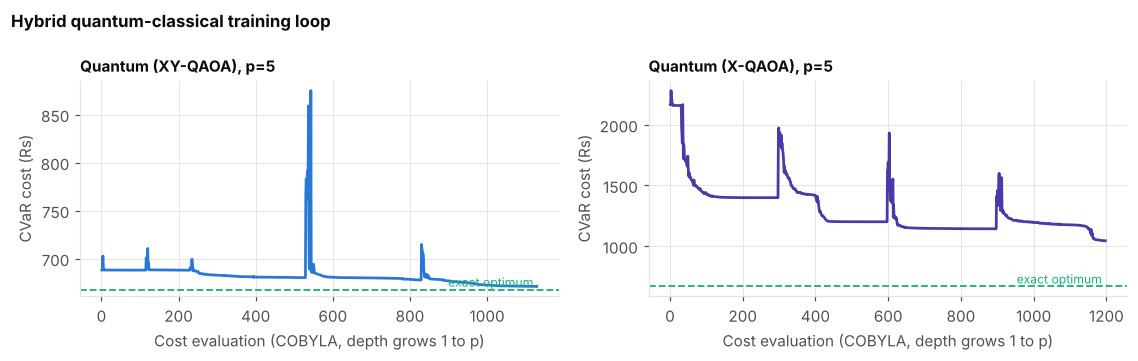

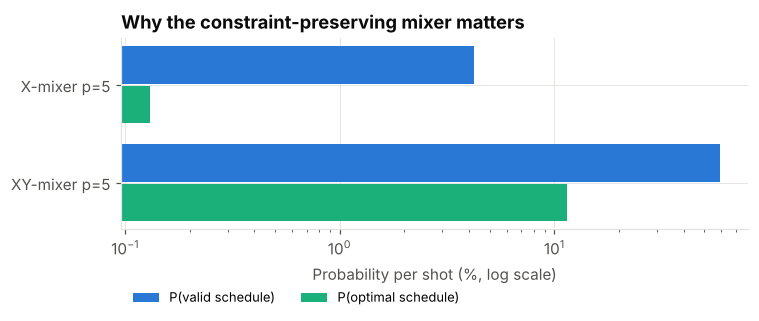

In [9]:
xq = solve_qaoa(q.Q, q.offset, E, feas, p=P, alpha=0.25, seed=7)
cmp = pd.DataFrame([xy.summary(), xq.summary()])[["mixer", "p", "qubits", "cx_gates", "prob_feasible",
                                                   "prob_optimal", "found_optimum", "gap_pct", "runtime_s"]]
display(cmp)
viz.convergence_plot({"Quantum (XY-QAOA)": xy, "Quantum (X-QAOA)": xq});
viz.mixer_comparison_plot(cmp.assign(prob_optimal=cmp["prob_optimal"].replace(0, np.nan)));

## 7. Solution quality versus circuit depth

Deeper circuits concentrate more probability on the optimal schedule, at the price of more two-qubit gates.
This is the trade-off that will decide what fits on real noisy hardware.

,p,P(optimal) %,P(valid) %,CX gates,found optimum
0,1,2.39,63.84,163,True
1,2,2.35,63.47,253,True
2,3,5.72,31.81,343,True
3,4,4.95,50.64,433,True
4,5,11.49,58.80,523,True
5,6,15.40,56.50,613,True


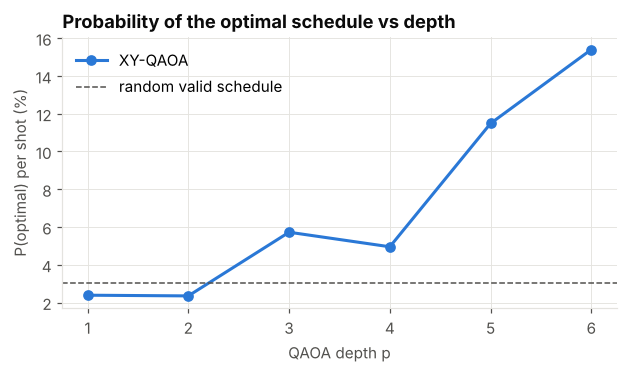

In [10]:
rows = []
for p in range(1, 7):
    r = solve_qaoa(q.Q_xy, q.offset_obj, E, feas, p=p, alpha=0.25, groups=q.groups, seed=7)
    rows.append({"p": p, "P(optimal) %": 100 * r.p_optimal, "P(valid) %": 100 * r.p_feasible,
                 "CX gates": r.cx_count, "found optimum": r.sampled_optimal})
depth = pd.DataFrame(rows); display(depth.round(2))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(depth["p"], depth["P(optimal) %"], marker="o", lw=2, color=viz.COLORS["Quantum (XY-QAOA)"], label="XY-QAOA")
ax.axhline(100 / feas.sum(), ls="--", color=viz.INK2, lw=1, label="random valid schedule")
ax.set_xlabel("QAOA depth p"); ax.set_ylabel("P(optimal) per shot (%)")
ax.set_title("Probability of the optimal schedule vs depth", loc="left"); ax.legend();

## 8. Results

Peak load: 72.2 -> 59.5 kW (-17.6%)
Energy cost: Rs 507 -> Rs 420 (-17.3%)


,feasible,peak_load_kw,energy_cost_rs,avg_wait_slots,detour_rs,objective_rs
FCFS,True,72.24,507.0,0.25,20.0,751.76
Classical optimum,True,59.51,419.5,1.0,0.0,667.8
Quantum (XY-QAOA),True,59.51,419.5,1.0,0.0,667.8
Simulated annealing,True,59.51,419.5,1.0,0.0,667.8


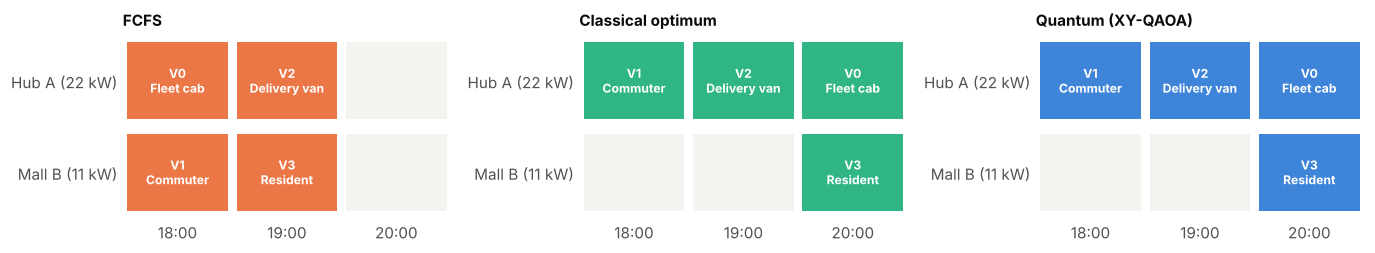

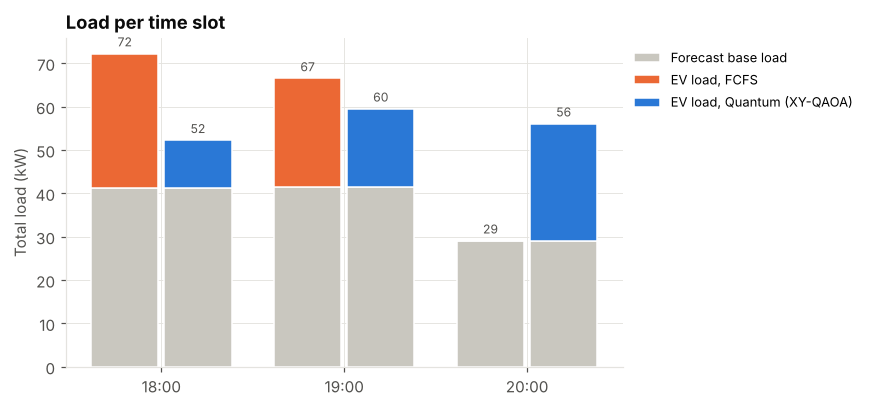

In [11]:
assign["Quantum (XY-QAOA)"] = bits_to_assignment(xy.best_bits, q)
sa_bits, _ = simulated_annealing(q, seed=7)
assign["Simulated annealing"] = bits_to_assignment(sa_bits, q)
metrics = {k: schedule_metrics(a, inst) for k, a in assign.items()}

viz.schedule_grid(inst, {k: assign[k] for k in ["FCFS", "Classical optimum", "Quantum (XY-QAOA)"]});
viz.load_plot(inst, {k: metrics[k] for k in ["FCFS", "Quantum (XY-QAOA)"]});

res = pd.DataFrame(metrics).T[["feasible", "peak_load_kw", "energy_cost_rs", "avg_wait_slots", "detour_rs", "objective_rs"]]
f = metrics["FCFS"]; qm = metrics["Quantum (XY-QAOA)"]
print(f"Peak load: {f['peak_load_kw']:.1f} -> {qm['peak_load_kw']:.1f} kW "
      f"({100*(qm['peak_load_kw']/f['peak_load_kw']-1):+.1f}%)")
print(f"Energy cost: Rs {f['energy_cost_rs']:.0f} -> Rs {qm['energy_cost_rs']:.0f} "
      f"({100*(qm['energy_cost_rs']/f['energy_cost_rs']-1):+.1f}%)")
res

## Takeaways and honest limitations

* The AI forecast feeds the Hamiltonian directly: change the forecast (or plan for P90) and the optimal schedule changes.
* Constraint-preserving XY-QAOA keeps most shots valid and finds the exact optimum; the standard X-mixer wastes most shots on invalid schedules.
* On this instance the optimized schedule cuts the evening peak and the energy bill versus first-come-first-served while every vehicle still charges before its deadline.
* All runs are noiseless simulations. At 15 to 19 qubits a classical solver is faster, so no quantum advantage is claimed.
  The value of the prototype is a working, verified hybrid pipeline that scales with better hardware.

**Next steps:** decomposition into time windows for city-scale instances, warm-start QAOA, noise models and IBM Quantum
hardware runs, rolling-horizon re-optimisation every few minutes, vehicle-to-grid discharge.